## **Aquisição de Imagens**

### **Classe A:** Assentos (Cadeiras e Bancos)
### **Classe B:** Calçados (Sapatos, Chinelas e Rasteirinhas)

  
* Dispositivo usado: smartphone Moto G52
* Condição de iluminação: Mista. Algumas imagens com iluminação natural, outras foram tiradas com iluminação artificial direta (LED 9W)
* Distância aproximada: entre 30 e 90cm
* Observações: algumas imagens apresentam muitas sombras e fundo proeminente, o que pode atrapalhar a aplicação de alguns filtros

## Transformações na imagem

In [1]:
!unzip -q dataset.zip -d /content/

In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
pasta_a = "/content/dataset/classe_a"
pasta_b = "/content/dataset/classe_b"

In [4]:
img_nome_a = [f for f in os.listdir(pasta_a) if f.lower().endswith(('png', 'jpg', 'jpeg'))][0]
img_nome_b = [f for f in os.listdir(pasta_b) if f.lower().endswith(('png', 'jpg', 'jpeg'))][0]

In [5]:
img_a_bgr = cv2.imread(os.path.join(pasta_a, img_nome_a))
img_b_bgr = cv2.imread(os.path.join(pasta_b, img_nome_b))

In [6]:
img_a = cv2.cvtColor(img_a_bgr, cv2.COLOR_BGR2RGB)
img_b = cv2.cvtColor(img_b_bgr, cv2.COLOR_BGR2RGB)

In [7]:
# =====================================================================
# PARTE A: ANÁLISE DE RESOLUÇÃO
# =====================================================================

def analisar_resolucoes(img, titulo_classe):
    res_original = img.copy()
    h, w, _ = res_original.shape

    w_50, h_50 = int(w * 0.50), int(h * 0.50)
    res_50 = cv2.resize(img, (w_50, h_50), interpolation=cv2.INTER_AREA)

    w_20, h_20 = int(w * 0.20), int(h * 0.20)
    res_20 = cv2.resize(img, (w_20, h_20), interpolation=cv2.INTER_AREA)

    # Plotagem comparativa
    fig, eixos = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Análise de Resolução - {titulo_classe}", fontsize=16, fontweight='bold')

    eixos[0].imshow(res_original)
    eixos[0].set_title(f"Original ({w}x{h})")
    eixos[0].axis('off')

    eixos[1].imshow(res_50)
    eixos[1].set_title(f"Reduzida 50% ({w_50}x{h_50})")
    eixos[1].axis('off')

    eixos[2].imshow(res_20)
    eixos[2].set_title(f"Reduzida 20% ({w_20}x{h_20})")
    eixos[2].axis('off')

    plt.tight_layout()
    plt.show()

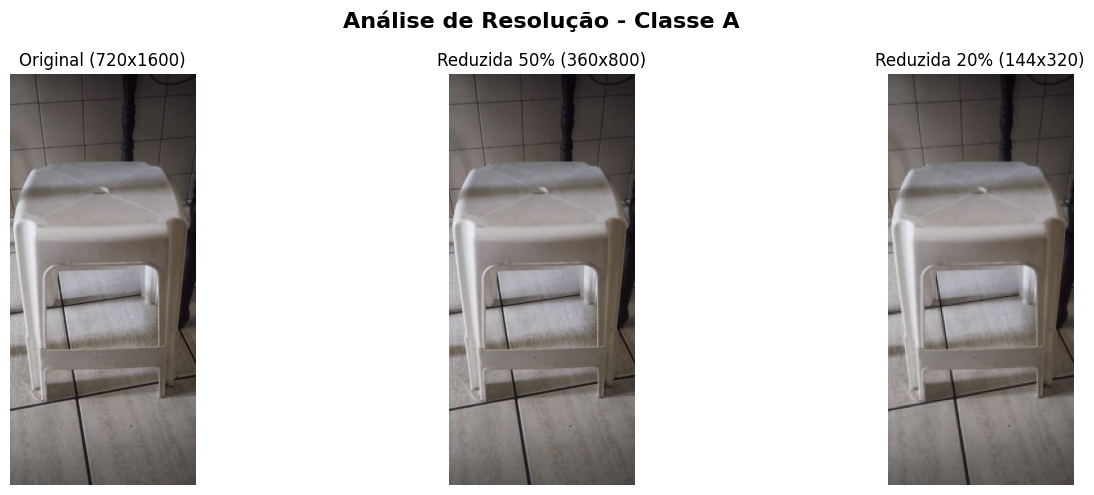

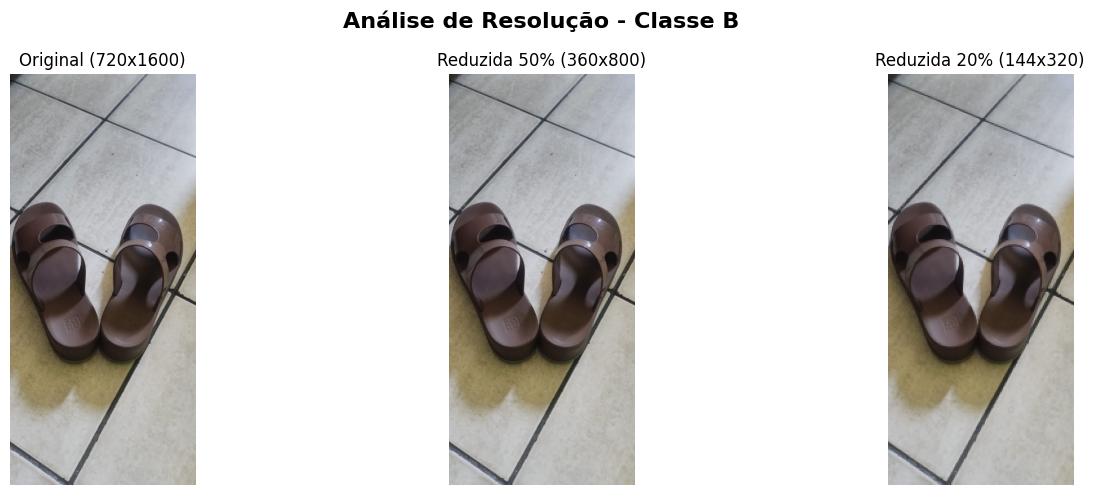

In [8]:
# Análise de resolução para as duas classes
analisar_resolucoes(img_a, "Classe A")
analisar_resolucoes(img_b, "Classe B")

In [ ]:
"""
======================
COMENTÁRIO
======================

Na redução de 50%, texturas finas e bordas sutis sofrem uma leve suavização. Já na redução de 20%, ocorre o
efeito de aliasing (pixelização agressiva): detalhes de alta frequência desaparecem completamente,
transformando-se em blocos homogêneos de cor.

Impacto em Visão Computacional: Reduzir a resolução diminui o custo computacional, acelerando as etapas de
treinamento de redes neurais. Contudo, se a tarefa exigir detecção de pequenos objetos, leitura de placas
(OCR) ou análise médica de texturas, a redução para 20% destruirá detalhes finos, degradando a acurácia do modelo
"""

In [10]:
# =====================================================================
# PARTE B: ESPAÇO DE COR
# =====================================================================

def analisar_espacos_cor(img_rgb, img_bgr, titulo_classe):
    rgb = img_rgb.copy()

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    cinza = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Plotagem comparativa
    fig, eixos = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Espaços de Cor - {titulo_classe}", fontsize=16, fontweight='bold')

    eixos[0].imshow(rgb)
    eixos[0].set_title("Espaço RGB")
    eixos[0].axis('off')

    # Exibir HSV com mapa de cor padrão para ver a separação de canais visualmente
    eixos[1].imshow(hsv)
    eixos[1].set_title("Espaço HSV (Visualização Direta)")
    eixos[1].axis('off')

    eixos[2].imshow(cinza, cmap='gray')
    eixos[2].set_title("Escala de Cinza")
    eixos[2].axis('off')

    plt.tight_layout()
    plt.show()

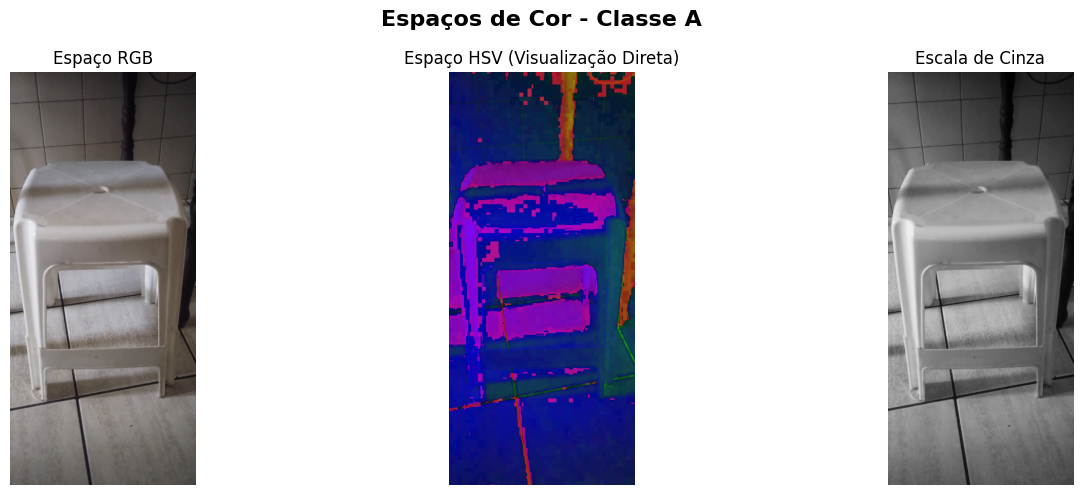

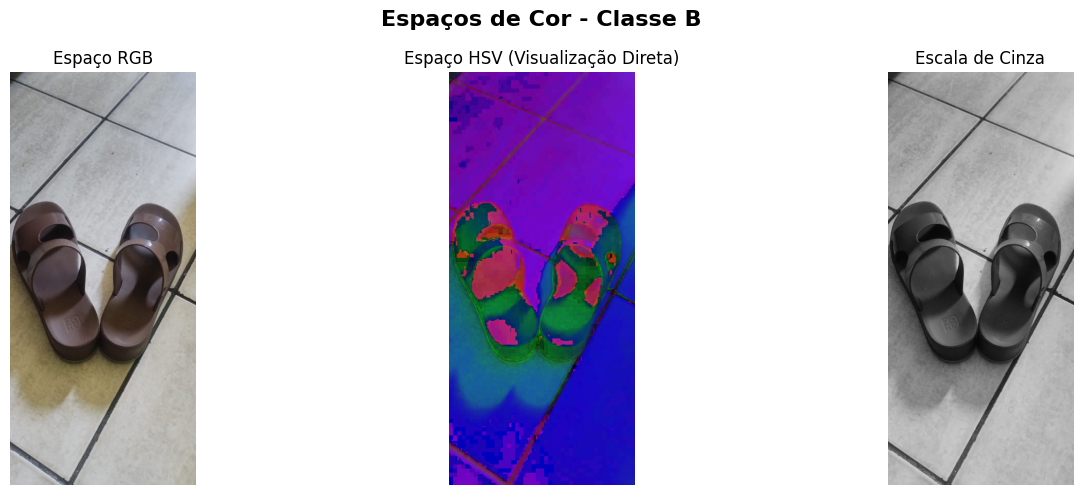

In [11]:
analisar_espacos_cor(img_a, img_a_bgr, "Classe A")
analisar_espacos_cor(img_b, img_b_bgr, "Classe B")

In [ ]:
"""
=============================
COMENTÁRIOS
=============================

1. Quais diferenças visuais aparecem ao converter?

RGB: Mostra a imagem com as cores naturais e intuitivas para o olho humano.
O brilho (luminosidade) está misturado e distribuído junto com a informação de cor em todos os três canais.

HSV: Visualmente gera cores não naturais quando plotado diretamente. Isso ocorre porque ele separa a
informação em Matiz/Tom (H), Saturação (S) e Valor/Brilho (V), fazendo regiões que possuem a mesma cor
(mesmo que uma esteja na sombra e a outra sob luz forte) aparecerem com valores muito similares no canal H.

Escala de Cinza: Elimina toda a informação cromática, mantendo puramente a intensidade luminosa (brilho)
de cada pixel variando de 0 a 255.


2. Em que tipo de tarefa você usaria cada uma?

RGB: Usado como entrada padrão para Redes Neurais Convolucionais modernas (CNNs e Transformers)
em tarefas complexas como classificação de imagens e segmentação semântica,
onde a cor real e o contexto de iluminação importam.

HSV: É o espaço de cor perfeito para Segmentação baseada em Cor (Color Thresholding) e rastreamento de
objetos coloridos simples (ex: seguir uma bola amarela ou isolar folhas verdes em plantações).
Como ele isola o brilho (V) da cor pura (H), algoritmos criados em HSV são extremamente imunes e
robustos contra variações de sombras e iluminação ambiente.

Escala de Cinza: Ideal para processamento clássico focado em Geometria e Forma, como detecção de bordas
(filtros Sobel/Canny), extração de contornos, transformações morfológicas e algoritmos de fluxo óptico.
Reduz o processamento de 3 canais para apenas 1 canal de cor, economizando memória computacional
sem perder a informação do objeto.

"""

In [12]:
# =====================================================================
# PARTE C: QUANTIZAÇÃO
# =====================================================================

def quantizar_imagem(img_bgr, niveis):
    """Reduz os níveis de intensidade da imagem em escala de cinza."""
    cinza = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    fator = 256 // niveis
    img_quantizada = (cinza // fator) * fator

    return img_quantizada

In [13]:
def analisar_quantizacao(img_bgr, titulo_classe):
    q_256 = quantizar_imagem(img_bgr, 256)
    q_64  = quantizar_imagem(img_bgr, 64)
    q_32  = quantizar_imagem(img_bgr, 32)
    q_2   = quantizar_imagem(img_bgr, 2) # Equivalente a uma binarização bruta

    fig, eixos = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f"Quantização - {titulo_classe}", fontsize=16, fontweight='bold')

    niveis_lista = [256, 64, 32, 2]
    imagens_lista = [q_256, q_64, q_32, q_2]

    for i in range(4):
        eixos[i].imshow(imagens_lista[i], cmap='gray', vmin=0, vmax=255)
        eixos[i].set_title(f"{niveis_lista[i]} Níveis")
        eixos[i].axis('off')

    plt.tight_layout()
    plt.show()

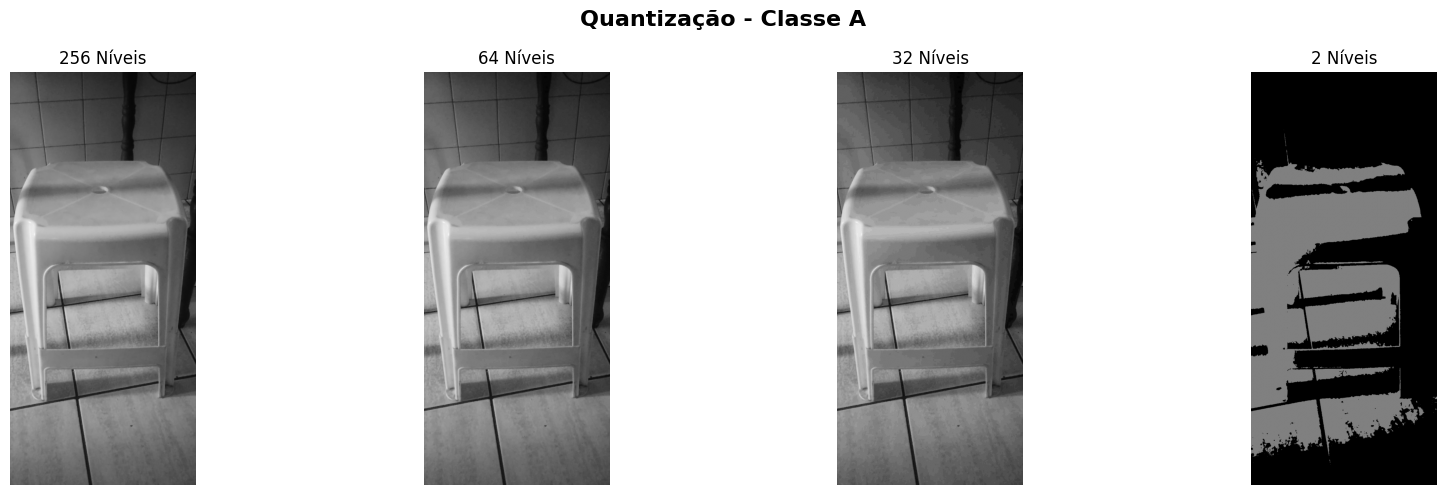

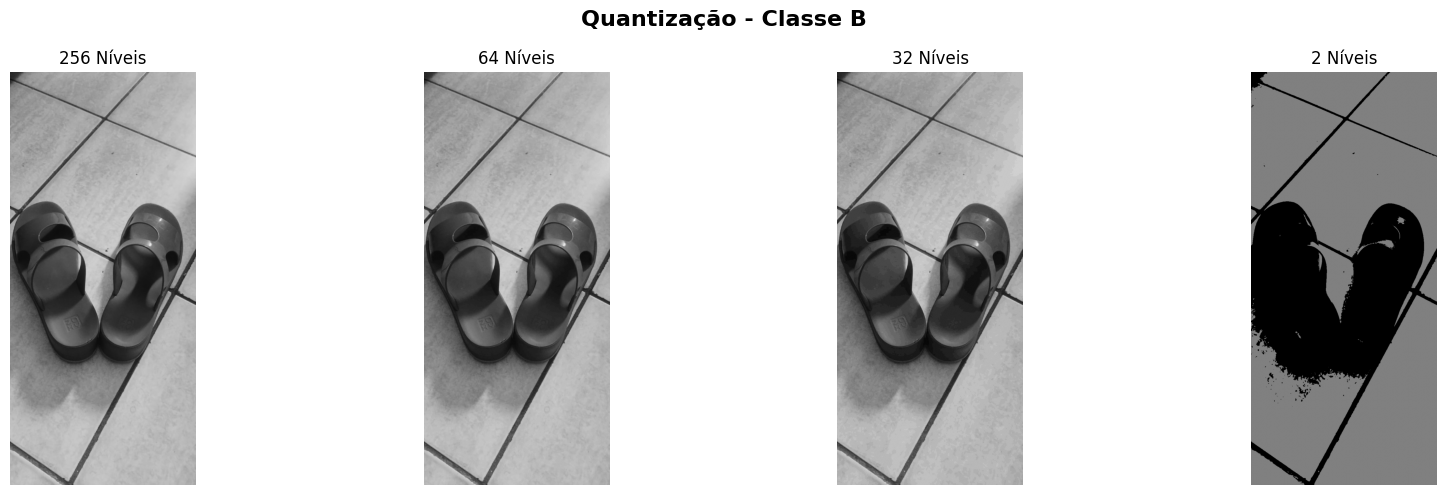

In [14]:
# Executar quantização para ambas as classes
analisar_quantizacao(img_a_bgr, "Classe A")
analisar_quantizacao(img_b_bgr, "Classe B")

In [28]:
# =====================================================================
# PARTE D: FORMATO DE ARQUIVO
# =====================================================================

def analisar_formatos(img_bgr, classe_nome):
    caminho_jpg = f"exemplo_{classe_nome}.jpg"
    caminho_png = f"exemplo_{classe_nome}.png"

    cv2.imwrite(caminho_jpg, img_bgr, [int(cv2.IMWRITE_JPEG_QUALITY), 30])
    cv2.imwrite(caminho_png, img_bgr, [int(cv2.IMWRITE_PNG_COMPRESSION), 0])

    tamanho_jpg = os.path.getsize(caminho_jpg) / 1024
    tamanho_png = os.path.getsize(caminho_png) / 1024

    print(f"\n" + "="*60)
    print(f" ANÁLISE DE ARQUIVO: {classe_nome.upper()}")
    print(f"="*60)
    print(f"-> JPEG (Com compressão):           {tamanho_jpg:.2f} KB")
    print(f"-> PNG  (Sem perdas):               {tamanho_png:.2f} KB")
    print(f"-> Razão de tamanho:                O PNG é {tamanho_png/tamanho_jpg:.1f}x maior.")
    print("="*60)

In [29]:
# Executar análise de formatos
analisar_formatos(img_a_bgr, "classe_a")
analisar_formatos(img_b_bgr, "classe_b")


 ANÁLISE DE ARQUIVO: CLASSE_A
-> JPEG (Com compressão):           36.18 KB
-> PNG  (Sem perdas):               3382.08 KB
-> Razão de tamanho:                O PNG é 93.5x maior.

 ANÁLISE DE ARQUIVO: CLASSE_B
-> JPEG (Com compressão):           40.95 KB
-> PNG  (Sem perdas):               3382.08 KB
-> Razão de tamanho:                O PNG é 82.6x maior.


In [ ]:
"""
=============================
COMENTÁRIOS
=============================

1. O que muda visualmente?

De 256 para 64 níveis: Quase imperceptível em condições normais, pois a transição de gradientes
ainda se comporta de forma suave.

32 níveis: Começa a apresentar o efeito de Falsa Borda. Começam a aparecer linhas artificiais, com mudanças
abruptas de tom.

2 níveis: Transforma-se em uma imagem puramente binária (preto ou branco absoluto).
Detalhes finos de textura, sombras e meio-tons são completamente aniquilados, restando apenas
silhuetas cruas de alto contraste.


2. Qual versão ainda seria mais útil para o seu dataset? E para qual aplicação?
A versão de 64 níveis ainda seria amplamente útil. Para algoritmos clássicos de Visão Computacional,
ela preserva virtualmente toda a informação estrutural e geométrica relevante enquanto reduz a
complexidade espacial dos dados.

Aplicação: Classificação e extração de características em datasets médicos ou industriais,
onde sutilezas de textura são críticas e não podem ser destruídas pelo efeito de falsa borda
(como ocorreria nas versões de 32 e 2 níveis).

"""